# DAY 2 - 모델 개발 및 평가

초기 100사이클의 특징으로 배터리 수명을 예측한다. **분할 단위는 셀**이다.

- Batch1: 학습용 셀 80%, 별도 Hold-out 20%; seed=42.
- 학습용 셀 안에서 5-fold CV로 후보를 선택하고 Hold-out으로 확인한다.
- 같은 충전 방식의 독립 셀은 양쪽에 들어갈 수 있다. 같은 셀은 섞이지 않는다.
- F0: 로그 ΔQ 분산. F1: F0 + 충전시간 중앙값 + 평균 Tavg.
- Batch2: 선택한 동일 모델을 적용한 MAPE 26.19%. 이전 평가 이력이 있는 재평가로 기록한다.

이번 변경은 과제의 셀 수명 예측 목적에 맞춰 과도했던 충전 방식별 분리를 제거한 것이다. 이전 Test 결과로 모델을 고르거나 수정 모델의 성능을 대신하지 않는다.

**보고서 연결:** 이 노트북은 해당 실험 단계의 실행 기록이다. 기존 셀 분리와 프로토콜 분리 결과를 함께 해석한 전체 결론은 [DAY2 보고서](../outputs/day2/DAY2_REPORT.md)에 있다.


## 1. 설정
기존 DAY1 노트북의 변수가 없어도 독립적으로 실행된다. 원본 MAT는 읽기만 한다.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image

# 프로젝트 루트 또는 notebooks/에서 실행
ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "day2_features.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "src" / "day2_features.py").exists(), "data_project 폴더에서 실행하세요."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.day2_features import extract_cell_features, attach_label_audit, F0, F1
from src.day2_modeling import run_development
from src.day2_evaluation import evaluate_holdout_model
BASE = ROOT / "outputs" / "day2"
OUTPUT = BASE / "modeling_cell_split"
OUTPUT.mkdir(parents=True, exist_ok=True)
SEED = 42
from src.run_day2 import save_provenance

## 2. 초기 특징 만들기
셀마다 한 행을 만든다. 실제 사이클 번호로 10번·100번의 Qdlin을 찾고, 두 곡선의 차이에서 분산을 계산한다. 전체 MAT를 메모리에 올리지 않고 필요한 데이터만 읽는다.

In [2]:
SAVED_RUN = (OUTPUT / "results.json").is_file()
features_raw = (pd.read_csv(OUTPUT / "cell_features.csv") if SAVED_RUN
                else extract_cell_features(ROOT / "data"))
display(features_raw.groupby("batch").agg(
    전체_셀수=("cell_id", "size"),
    수명값_존재=("cycle_life", "count"),
    ΔQ_계산완료=("delta_status", lambda s: s.eq("ok").sum()),
))
display(features_raw.loc[features_raw.cycle_life.notna(),
    ["batch", "cell_id", "cycle_life"] + F1].head().round(5))

,전체_셀수,수명값_존재,ΔQ_계산완료
batch,,,
Batch1,46,46,46
Batch2,47,39,47
Batch3,46,44,46


,batch,cell_id,cycle_life,log10_delta_Q_var,median_chargetime,mean_Tavg
0,Batch1,0,1190.0,-5.01486,13.35821,31.60375
1,Batch1,1,1179.0,-5.01396,13.34162,31.33031
2,Batch1,2,1177.0,-4.73700,13.34157,31.47958
3,Batch1,3,1226.0,-4.44261,12.09224,29.94220
4,Batch1,4,1227.0,-4.64774,12.09220,31.44888


## 3. 수명 레이블과 사용 셀 확정

Batch1 **36개 셀**을 사용하고, 연속 실험의 병합이 필요한 0-4번과 미완료 8·10·12·13·22번은 제외한다(모두 0부터 시작하는 cell_id).

남은 36개의 마지막 관측 용량은 0.880057-0.883363 Ah이며 제공된 수명값은 기록 최대 사이클+1이다. 엄격한 0.88 Ah 미만 도달은 관측되지 않았다. 따라서 이번 모델은 **제공 수명 레이블의 회귀**이며 정확한 EOL 도달을 직접 확인한 Target이라고 표현하지 않는다. 0.885 Ah 이내 종료는 사전에 정한 감사 기준이지 공식 Batch1 EOL 기준을 바꾼 것이 아니다.

수명 결측은 대체하지 않고, 다른 셀의 수명도 재계산하지 않는다. 전체 수명 기록의 감사 숫자는 모델 입력과 분리한다.

In [3]:
audit = pd.read_csv(BASE / "label_audit.csv")
features = features_raw.copy() if SAVED_RUN else attach_label_audit(features_raw, audit)
if not SAVED_RUN:
    features.to_csv(OUTPUT / "cell_features.csv", index=False)
display(features.groupby(["batch", "label_status"], dropna=False).agg(
    셀수=("cell_id", "size"), 사용가능=("model_eligible", "sum")
))
display(features.loc[(features.batch == "Batch1") & ~features.model_eligible,
    ["cell_id", "cycle_life", "label_status", "delta_status"]])

셀수  사용가능
batch  label_status                                
Batch1 exclude_continuation_pending_merge   5     0
       exclude_official_unfinished          5     0
       stop_boundary_asprovided            36    36
Batch2 missing_raw_target                   8     0
       observed_crossing_matches_raw       39     0
Batch3 missing_raw_target                   2     0
       stop_boundary_asprovided            44     0

,cell_id,cycle_life,label_status,delta_status
0,0,1190.0,exclude_continuation_pending_merge,ok
1,1,1179.0,exclude_continuation_pending_merge,ok
2,2,1177.0,exclude_continuation_pending_merge,ok
3,3,1226.0,exclude_continuation_pending_merge,ok
4,4,1227.0,exclude_continuation_pending_merge,ok
8,8,879.0,exclude_official_unfinished,ok
10,10,906.0,exclude_official_unfinished,ok
12,12,902.0,exclude_official_unfinished,ok
13,13,897.0,exclude_official_unfinished,ok
22,22,891.0,exclude_official_unfinished,ok


## 4. 셀 단위 분할과 모델 비교

Batch1의 사용 가능한 36개 셀을 먼저 학습용 28개와 Hold-out 8개로 나눈다. 학습용 셀에서 KFold(5, shuffle=True, random_state=42)를 사용하며 모든 후보가 같은 폴드를 사용한다. 사이클 행을 무작위로 나누는 것이 아니라 **셀 전체를 분리**한다.

평균 예측, 선형 회귀 F0/F1, Ridge, Elastic Net의 15개 설정을 비교한다. ΔQ가 가장 일관된 신호였으므로 F0를 기준으로 추가 특징과 규제의 효과를 확인한다. 후보 선택은 CV 평균 MAPE만 사용한다.

결측 대체와 표준화는 Pipeline 안에서 각 학습 폴드에만 fit한다. 검증 폴드에는 transform만 적용한다. 실제 knee나 후기 열화 속도는 예측 시점 이후 정보이므로 입력에서 제외한다.

In [4]:
if SAVED_RUN:
    saved = json.loads((OUTPUT / "results.json").read_text(encoding="utf-8"))
    assert saved["metadata"]["seed"] == SEED
    results = {"comparison_df": pd.read_csv(OUTPUT / "model_comparison.csv"),
               "oof_df": pd.read_csv(OUTPUT / "oof_predictions.csv"),
               "selected_name": saved["selected_name"]}
else:
    results = run_development(features, OUTPUT, seed=SEED)
comparison = results["comparison_df"]
display(comparison[["candidate", "feature_set", "alpha", "l1_ratio", "cv_mean_mape_pct", "oof_mape_pct", "oof_mae", "oof_rmse"]].round(4))
print("CV 기준 추천 후보:", results["selected_name"])
print("이 표는 모델 선택을 위한 CV 결과입니다. 아래에서 선택 모델의 Hold-out만 확인합니다.")

,candidate,feature_set,alpha,l1_ratio,cv_mean_mape_pct,oof_mape_pct,oof_mae,oof_rmse
0,linear_F0,F0,NaN,NaN,9.2845,9.1950,74.4700,92.1233
1,elasticnet_F1_alpha_0.1_l1_ratio_0.1,F1,0.1,0.1,9.8211,9.6240,75.5109,90.2790
2,elasticnet_F1_alpha_0.1_l1_ratio_0.5,F1,0.1,0.5,9.8295,9.6440,75.6515,90.4884
3,ridge_F1_alpha_1,F1,1.0,NaN,9.8342,9.6498,75.6868,90.5154
4,ridge_F1_alpha_0.1,F1,0.1,NaN,9.8981,9.7243,76.2271,91.3194
5,linear_F1,F1,NaN,NaN,9.9071,9.7346,76.3060,91.4603
6,ridge_F1_alpha_10,F1,10.0,NaN,10.6547,10.4080,81.0565,94.5066
7,elasticnet_F1_alpha_1_l1_ratio_0.5,F1,1.0,0.5,10.8320,10.5805,82.2643,95.6167
8,elasticnet_F1_alpha_1_l1_ratio_0.1,F1,1.0,0.1,11.7391,11.4786,88.7747,102.0164
9,ridge_F1_alpha_100,F1,100.0,NaN,14.5778,14.3047,109.3865,128.7853


CV 기준 추천 후보: linear_F0
이 표는 모델 선택을 위한 CV 결과입니다. 아래에서 선택 모델의 Hold-out만 확인합니다.


## 5. 오차가 어디에서 발생하는가?
각 셀은 자신이 들어 있지 않은 폴드의 모델로 예측한다(OOF). 아래 그림은 추천 후보의 개발 단계 진단이며, 최종 일반화 성능을 확정하는 결과는 아니다.

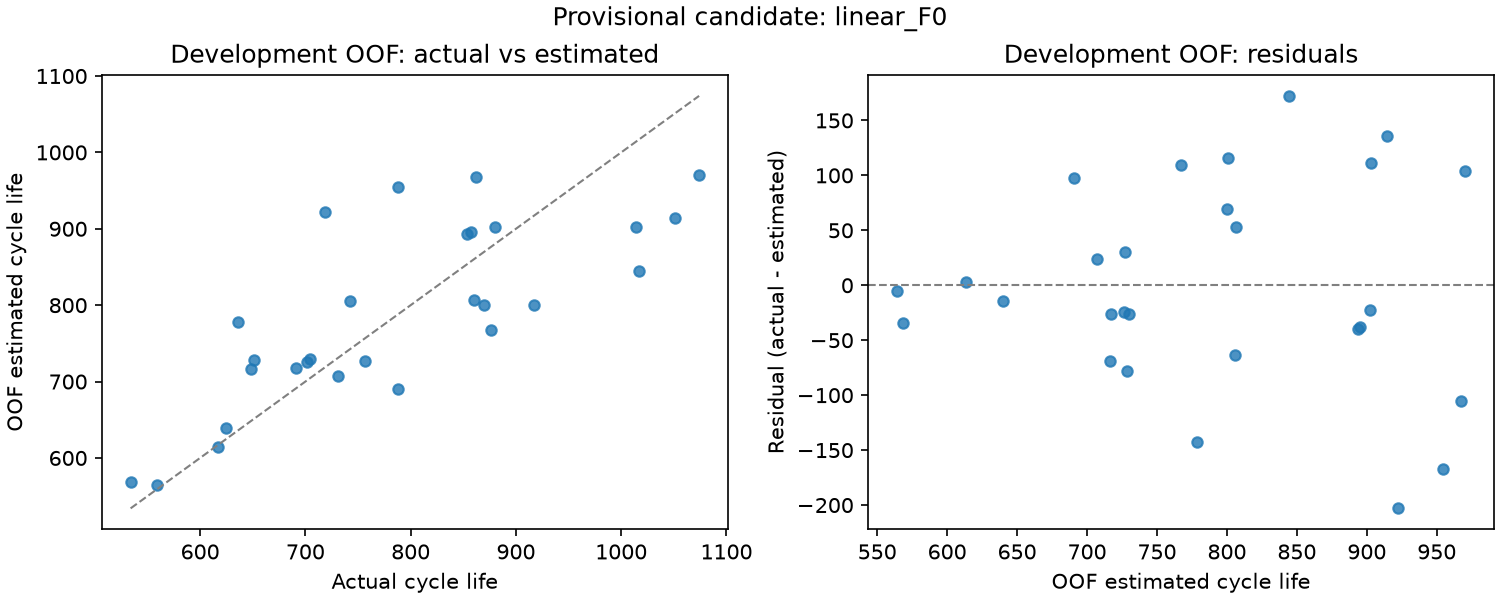

,candidate,batch,cell_id,charging_policy,policy_group,role,fold,actual,estimated,residual,absolute_percentage_error_pct,negative_prediction
28,linear_F0,Batch1,11,5.4C(50%)-3C,5.4C(50%)-3C,development,1,788.0,954.747,-166.747,21.161,False
29,linear_F0,Batch1,14,5.4C(60%)-3C,5.4C(60%)-3C,development,2,880.0,902.308,-22.308,2.535,False
30,linear_F0,Batch1,15,5.4C(60%)-3C,5.4C(60%)-3C,development,3,719.0,922.007,-203.007,28.235,False
31,linear_F0,Batch1,16,5.4C(60%)-3.6C,5.4C(60%)-3.6C,development,3,862.0,967.326,-105.326,12.219,False
32,linear_F0,Batch1,17,5.4C(60%)-3.6C,5.4C(60%)-3.6C,development,3,857.0,895.421,-38.421,4.483,False


In [5]:
display(Image(filename=str(OUTPUT / "selected_oof_diagnostics.png")))
selected_oof = results["oof_df"].loc[results["oof_df"]["candidate"].eq(results["selected_name"])].copy()
display(selected_oof.head().round(3))

## 6. 분할 및 입력 시점 확인

같은 셀의 기록이 학습과 Hold-out에 동시에 들어가지 않았는지 확인한다. 충전 방식의 중복은 허용한다. C1·전환 SOC·C2는 참고용으로 보관하지만 이번 F0/F1 후보에는 사용하지 않는다. 측정 입력은 실제 사이클 100번까지이며 Target은 제공된 수명값이다.

In [6]:
manifest = pd.read_csv(OUTPUT / "split_manifest.csv", dtype={"cell_id": str})
display(manifest.groupby(["batch", "role"]).size().rename("셀수").to_frame())
dev_ids = set(manifest.loc[manifest.role.eq("development"), "cell_id"])
valid_ids = set(manifest.loc[manifest.role.eq("holdout"), "cell_id"])
assert dev_ids.isdisjoint(valid_ids)
assert len(dev_ids) == 28 and len(valid_ids) == 8
assert features.input_max_cycle.dropna().le(100).all()
assert not manifest.duplicated(["batch", "cell_id"]).any()
assert results["oof_df"].batch.eq("Batch1").all()
print("셀 중복 없음 / 초기 100사이클 입력 / Batch2·3 학습 및 CV 제외")

셀수
batch  role                 
Batch1 development        28
       excluded           10
       holdout             8
Batch2 excluded            8
       external_reserved  39
Batch3 excluded            2
       external_reserved  44

셀 중복 없음 / 초기 100사이클 입력 / Batch2·3 학습 및 CV 제외


## 7. Hold-out 확인 및 성능 보고

CV로 선택한 모델을 학습용 28개 셀에 학습한 그대로 Hold-out 8개에 적용한다. 이 결과로 다른 후보를 다시 선택하지 않는다. 이전 실행에서 Batch1 전체를 개발에 사용했으므로 이번 Hold-out은 개발 확인용이며 새로운 독립 Test는 아니다.

Batch2의 이전 점수는 이전 분할에서 학습한 모델의 점수다. 아래 Hold-out 단계에서는 Test를 사용하지 않고, 마지막 셀에서 사용자가 요청한 Batch2 평가를 수행한다. 같은 모델·입력의 재실행은 저장된 Hold-out 평가를 사용한다.

,구분,MAPE (%),비고
0,Train (Batch 1 CV),9.285,셀 단위 5-fold MAPE 산술 평균
1,Valid (Batch 1 Hold-out),6.439,8개 셀; 같은 최종 모델
2,Test (Batch 2),미평가,이 단계에서는 Hold-out만 확인; Batch2는 최종 평가에서 확인
3,Gap (Train-Valid),-2.846,Valid - Train; (+): 과적합 또는 조건 차이 의심
4,Gap (Valid-Test),미평가,이 단계에서는 Hold-out만 확인; Batch2는 최종 평가에서 확인
5,Gap (Target-Test),미평가,이 단계에서는 Hold-out만 확인; Batch2는 최종 평가에서 확인


,split,n,mape_pct,mae,rmse,r2
0,Valid,8,6.439,54.958,67.986,0.806


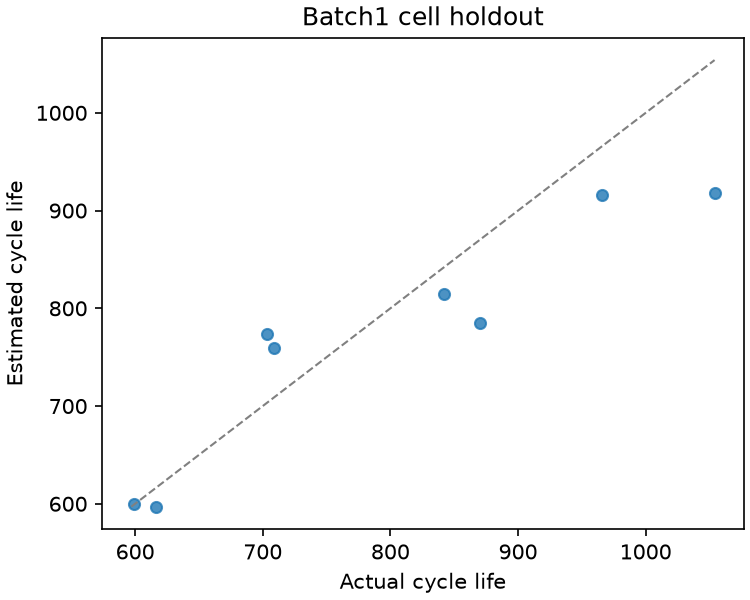

In [7]:
evaluation = evaluate_holdout_model(features, OUTPUT)
display(evaluation["report"].round(3).fillna("미평가"))
display(pd.read_csv(OUTPUT / "holdout_metrics.csv").round(3))
display(Image(filename=str(OUTPUT / "holdout_evaluation.png")))
if not SAVED_RUN:
    save_provenance(ROOT, OUTPUT, BASE / "label_audit.csv", SEED)

## 선행 연구와 이번 구현의 차이

- [Severson et al. (2019), 저자 공개 논문](https://petermattia.com/papers/Severson%2C%20Attia%20et%20al.%20-%202019%20-%20Data-driven%20prediction%20of%20battery%20cycle%20life%20before%20capacity%20degradation.pdf): 로그 수명을 Elastic Net으로 예측. 이번 구현은 F0·F1의 원 수명 Target을 유지하며 규제 후보만 참고한다.
- [같은 데이터 재분석, Attia et al.](https://arxiv.org/pdf/2101.01885v2): 특징과 모델 선택을 다시 검토한 사례. Elastic Net이 항상 Ridge보다 우수하다는 근거는 아니다.
- [연구팀 공식 데이터 처리 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m): 로컬 Batch2(2018-02-20)는 논문 Batch2(2017-06-30)와 파일명이 달라 셀 번호를 그대로 가져오지 않는다.

논문의 Test 오차를 우리 모델 성능으로 인용하지 않는다.

## 8. 재현성 및 해석 기준

- 분할과 CV의 random_state=42. Elastic Net에도 seed를 기록한다. 다른 후보는 결정론적 설정이다.
- 라이브러리 버전과 분할 셀·폴드·모델 설정은 metadata.json 및 split_manifest.csv에 기록한다.
- 원본 파일 이름·크기·수정 시점, 입력 CSV 및 레이블 감사 파일의 해시, 실행 코드 해시는 provenance.json에 기록한다.
- Train은 CV의 검증 MAPE 산술 평균이다. 학습 셀을 다시 예측한 오차와 구분한다.
- Gap (Train-Valid) = Valid - CV이며 단위는 %p이다. 8개 Hold-out만으로 과적합 여부를 단정하지 않는다.
- MAPE를 주 지표로, MAE·RMSE·R²를 보조 지표로 남긴다. CV는 후보 선택에 사용했으므로 독립적인 최종 성능이 아니다.
- 셀 단위 분할의 모델·예측·평가 결과는 outputs/day2/modeling_cell_split/에 저장한다.
- Batch2 MAPE는 26.19%로 논문 참고값 9.1%를 달성하지 못했다. 이전 평가 이력이 있는 재평가로 구분한다. 로컬 Batch2 파일·사용 셀·특징·Target 변환이 달라 정확한 논문 재현과도 구분해야 한다.
- 실제 운영에서는 초기 특징 분포 변화를 확인하고 수명 정답이 확보되면 오차를 점검한다. 이는 운영 계획이며 이번에 Live Test나 자동 재학습을 수행한 것은 아니다.

## 9. 선택한 모델을 Batch2에 적용

이미 학습한 모델과 전처리를 고정하고 수명값이 있는 Batch2 39개 셀을 평가한다. Batch2로 fit하거나 모델을 다시 선택하지 않는다. 이전 평가 이력이 있으므로 새 독립 Test라고 표현하지 않는다. 동일 모델·입력의 재실행은 저장된 결과를 사용한다.

,구분,MAPE (%),비고
0,Train (Batch 1 CV),9.285,셀 단위 5-fold MAPE 산술 평균
1,Valid (Batch 1 Hold-out),6.439,8개 셀; 같은 최종 모델
2,Test (Batch 2),26.186,39개 셀; 고정 모델 재평가
3,Gap (Train-Valid),-2.846,Valid - Train; (+): 과적합 또는 조건 차이 의심
4,Gap (Valid-Test),19.747,Test - Valid; (+): 배치 간 일반화 저하 의심
5,Gap (Target-Test),17.086,Test - 9.1%; 과제에서 제시한 원논문 참고값


,split,n,mape_pct,mae,rmse,r2
0,Valid,8,6.439,54.958,67.986,0.806
1,Test Batch2,39,26.186,131.481,152.511,0.517


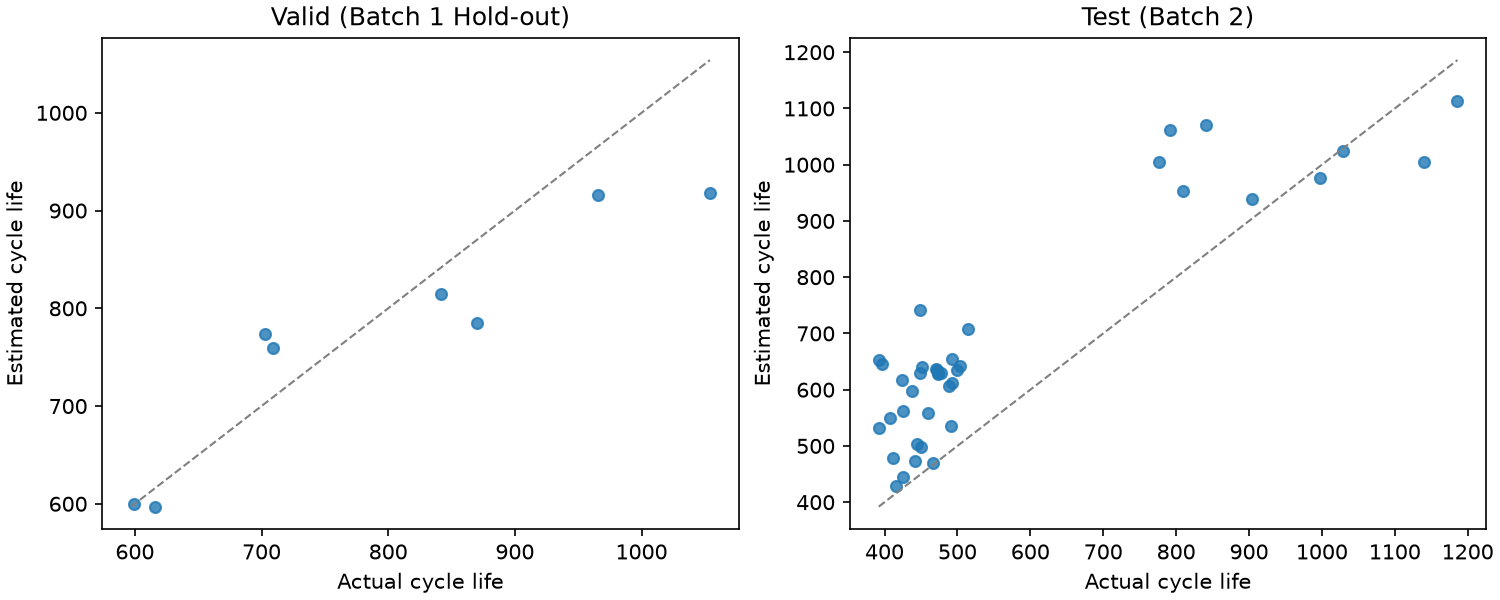

,evaluation,life_band,n,mape_pct,mean_residual
0,Test (Batch 2),<=500,28,29.389,-130.501
1,Test (Batch 2),500-1000,8,22.484,-152.350
2,Test (Batch 2),>1000,3,6.157,70.966
3,Valid (Batch 1 Hold-out),500-1000,7,5.513,8.522
4,Valid (Batch 1 Hold-out),>1000,1,12.921,136.183


In [8]:
from src.day2_evaluation import evaluate_frozen_model

# 기존에 저장한 선택 모델을 그대로 불러온다. 학습 및 튜닝 없음.
features_for_test = pd.read_csv(OUTPUT / "cell_features.csv")
test_evaluation = evaluate_frozen_model(features_for_test, OUTPUT, allow_retest=True)
display(test_evaluation["report"].round(3))
display(pd.read_csv(OUTPUT / "evaluation_metrics.csv").round(3))
display(Image(filename=str(OUTPUT / "final_evaluation.png")))
display(pd.read_csv(OUTPUT / "evaluation_segments.csv").round(3))